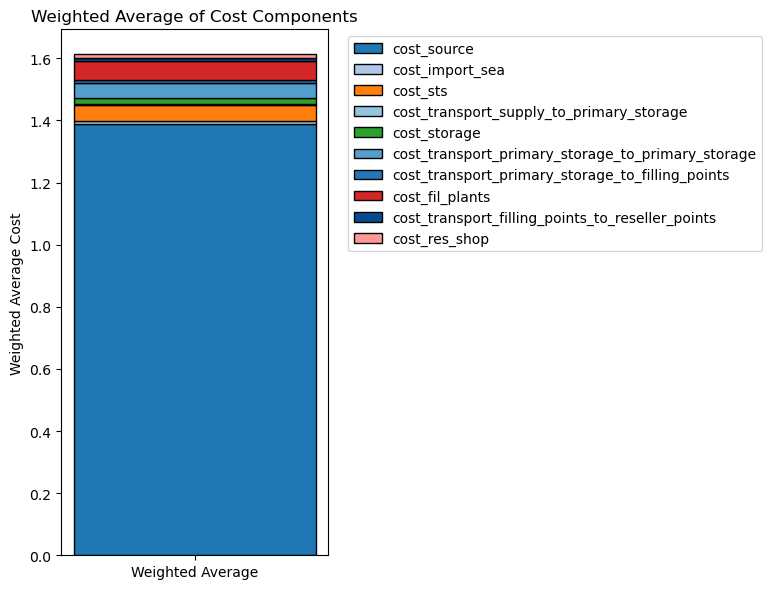

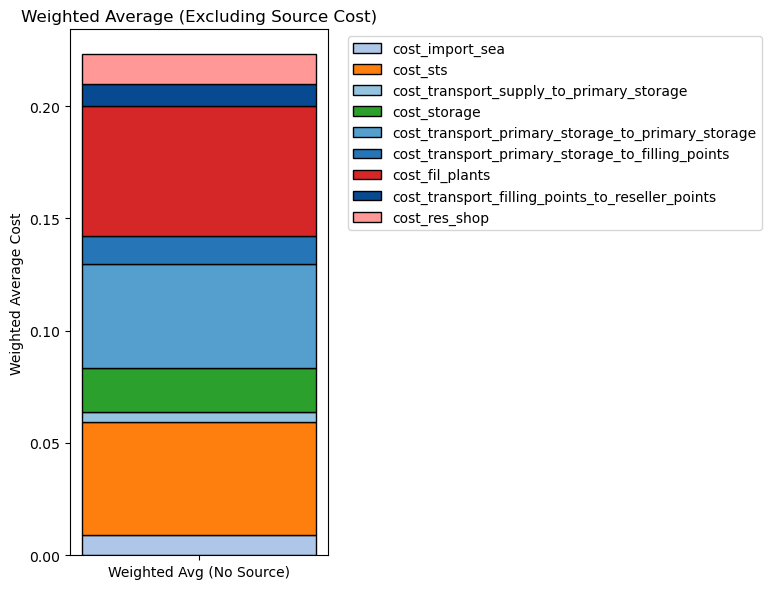

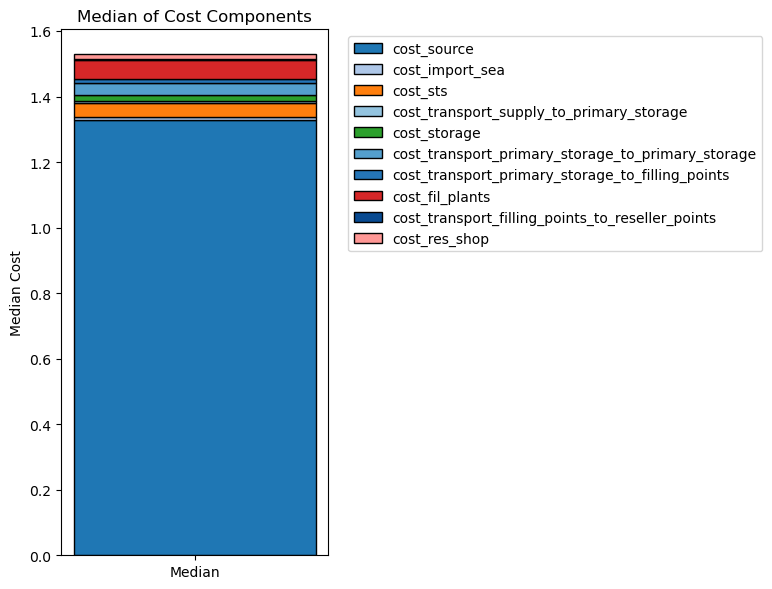

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Load the dataset
file_path = r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\dataset\supply_chain_layer_NGA_sensitivity_2.gpkg"
layer_name = "reseller_points"

gdf = gpd.read_file(file_path, layer=layer_name)
clients_col = 'clients'

# 2. Select cost columns
cost_cols = [col for col in gdf.columns if str(col).startswith('cost_') and pd.api.types.is_numeric_dtype(gdf[col])]
if 'cost_total' in cost_cols:
    cost_cols.remove('cost_total')

gdf_clean = gdf.dropna(subset=[clients_col]).copy()

# Calculation 1: Weighted average
weighted_avg = {}
for col in cost_cols:
    valid_data = gdf_clean.dropna(subset=[col])
    total_valid_clients = valid_data[clients_col].sum()
    if total_valid_clients > 0:
        weighted_avg[col] = (valid_data[col] * valid_data[clients_col]).sum() / total_valid_clients
    else:
        weighted_avg[col] = 0

# Calculation 2: Weighted average excluding "cost_source"
weighted_avg_no_source = {col: val for col, val in weighted_avg.items() if col != 'cost_source'}

# Calculation 3: Median
medians = gdf[cost_cols].median().to_dict()

# --- Color Mapping Logic ---
# Identify transport costs vs other costs
transport_cols = [col for col in cost_cols if col.startswith('cost_transport_')]
other_cols = [col for col in cost_cols if col not in transport_cols]

cost_colors = {}

# Assign similar colors (shades of Blue) to transport costs
transport_cmap = cm.Blues
for i, col in enumerate(transport_cols):
    # Avoid colors that are too light to see on a white background (start from 0.4)
    shade_intensity = 0.4 + (0.5 * (i / max(1, len(transport_cols) - 1))) 
    cost_colors[col] = transport_cmap(shade_intensity)

# Assign distinct, separate colors to all other costs
other_cmap = cm.tab20
for i, col in enumerate(other_cols):
    cost_colors[col] = other_cmap(i % 20)

# 3. Create the plots
def plot_stacked_bar(data_dict, title, ylabel, bar_label):
    plt.figure(figsize=(8, 6))
    bottom = 0
    
    for cost_name, value in data_dict.items():
        # Exclude components with a value of 0
        if value > 0:
            plt.bar(
                bar_label, 
                value, 
                bottom=bottom, 
                label=cost_name, 
                color=cost_colors[cost_name], 
                edgecolor='black'
            )
            bottom += value
            
    plt.title(title)
    plt.ylabel(ylabel)
    
    # Only show legend if there are valid items plotted
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.tight_layout()
    plt.show()

# Generate the 3 separate plots
plot_stacked_bar(
    data_dict=weighted_avg, 
    title='Weighted Average of Cost Components', 
    ylabel='Weighted Average Cost', 
    bar_label='Weighted Average'
)

plot_stacked_bar(
    data_dict=weighted_avg_no_source, 
    title='Weighted Average (Excluding Source Cost)', 
    ylabel='Weighted Average Cost', 
    bar_label='Weighted Avg (No Source)'
)

plot_stacked_bar(
    data_dict=medians, 
    title='Median of Cost Components', 
    ylabel='Median Cost', 
    bar_label='Median'
)


--- Weighted Average ---
                                   Cost Component    Value
                                      cost_source 1.389840
                                  cost_import_sea 0.009031
                                         cost_sts 0.050281
         cost_transport_supply_to_primary_storage 0.004317
                                     cost_storage 0.019968
cost_transport_primary_storage_to_primary_storage 0.046096
 cost_transport_primary_storage_to_filling_points 0.012385
                                  cost_fil_plants 0.058190
 cost_transport_filling_points_to_reseller_points 0.009728
                                    cost_res_shop 0.013059
                                            Total 1.612894

--- Weighted Average (No Source) ---
                                   Cost Component    Value
                                  cost_import_sea 0.009031
                                         cost_sts 0.050281
         cost_transport_supply_to_primary_storage 0

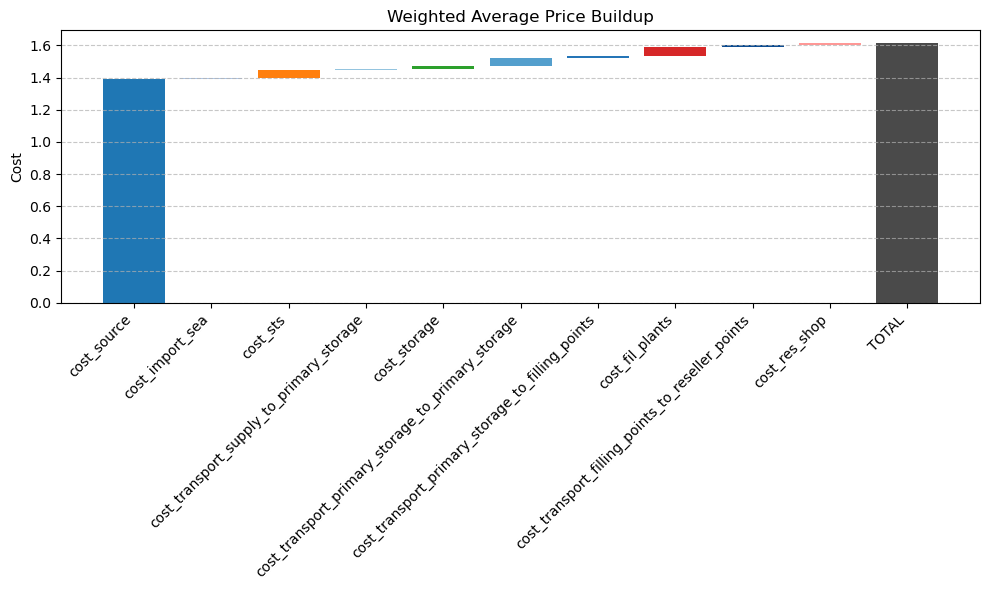

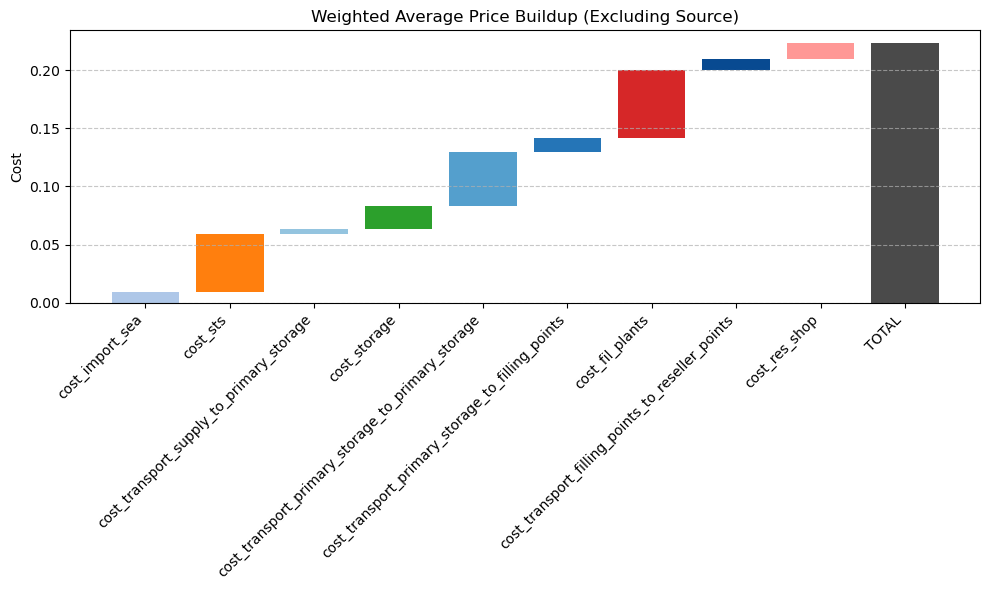

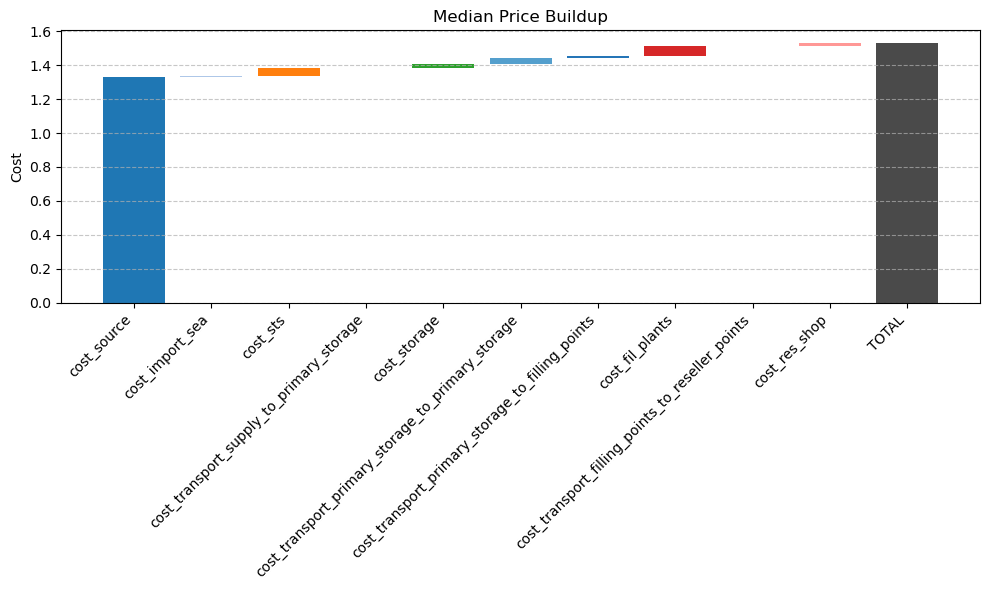

In [4]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Load the dataset
file_path = file_path
layer_name = "reseller_points"

gdf = gpd.read_file(file_path, layer=layer_name)
clients_col = 'clients'

# 2. Select cost columns
cost_cols = [col for col in gdf.columns if str(col).startswith('cost_') and pd.api.types.is_numeric_dtype(gdf[col])]
if 'cost_total' in cost_cols:
    cost_cols.remove('cost_total')

gdf_clean = gdf.dropna(subset=[clients_col]).copy()

# Calculation 1: Weighted average
weighted_avg = {}
for col in cost_cols:
    valid_data = gdf_clean.dropna(subset=[col])
    total_valid_clients = valid_data[clients_col].sum()
    if total_valid_clients > 0:
        weighted_avg[col] = (valid_data[col] * valid_data[clients_col]).sum() / total_valid_clients
    else:
        weighted_avg[col] = 0

# Calculation 2: Weighted average excluding "cost_source"
weighted_avg_no_source = {col: val for col, val in weighted_avg.items() if col != 'cost_source'}

# Calculation 3: Median
medians = gdf[cost_cols].median().to_dict()

# --- Color Mapping Logic ---
transport_cols = [col for col in cost_cols if col.startswith('cost_transport_')]
other_cols = [col for col in cost_cols if col not in transport_cols]

cost_colors = {}
transport_cmap = cm.Blues
for i, col in enumerate(transport_cols):
    shade_intensity = 0.4 + (0.5 * (i / max(1, len(transport_cols) - 1))) 
    cost_colors[col] = transport_cmap(shade_intensity)

other_cmap = cm.tab20
for i, col in enumerate(other_cols):
    cost_colors[col] = other_cmap(i % 20)

# --- Print Tables ---
def print_table(data_dict, title):
    # Filter out 0 values for the table as well
    filtered_data = {k: v for k, v in data_dict.items() if v > 0}
    filtered_data['Total'] = sum(filtered_data.values())
    df = pd.DataFrame(list(filtered_data.items()), columns=['Cost Component', 'Value'])
    print(f"\n--- {title} ---")
    print(df.to_string(index=False))

print_table(weighted_avg, "Weighted Average")
print_table(weighted_avg_no_source, "Weighted Average (No Source)")
print_table(medians, "Medians")

# --- Waterfall Plot Logic ---
def plot_waterfall(data_dict, title, ylabel):
    # Filter 0 values
    data = {k: v for k, v in data_dict.items() if v > 0}
    if not data:
        return
    
    labels = list(data.keys()) + ['TOTAL']
    values = list(data.values())
    total_val = sum(values)
    values.append(total_val)
    
    # Calculate bottom positions for the floating bars
    bottoms = []
    current_bottom = 0
    
    for i, val in enumerate(values[:-1]):
        if i == 0:
            bottoms.append(0)  # First bar starts at 0
        else:
            bottoms.append(current_bottom) # Subsequent bars float
        current_bottom += val
        
    bottoms.append(0)  # Final Total bar starts at 0
    
    # Set colors
    colors = [cost_colors.get(label, '#1f77b4') for label in labels[:-1]]
    colors.append('#4a4a4a')  # Dark grey for the TOTAL bar
    
    plt.figure(figsize=(10, 6))
    
    plt.bar(labels, values, bottom=bottoms, color=colors, edgecolor='none')
    
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    
    # Add horizontal gridlines for readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Generate the 3 waterfall plots
plot_waterfall(weighted_avg, 'Weighted Average Price Buildup', 'Cost')
plot_waterfall(weighted_avg_no_source, 'Weighted Average Price Buildup (Excluding Source)', 'Cost')
plot_waterfall(medians, 'Median Price Buildup', 'Cost')

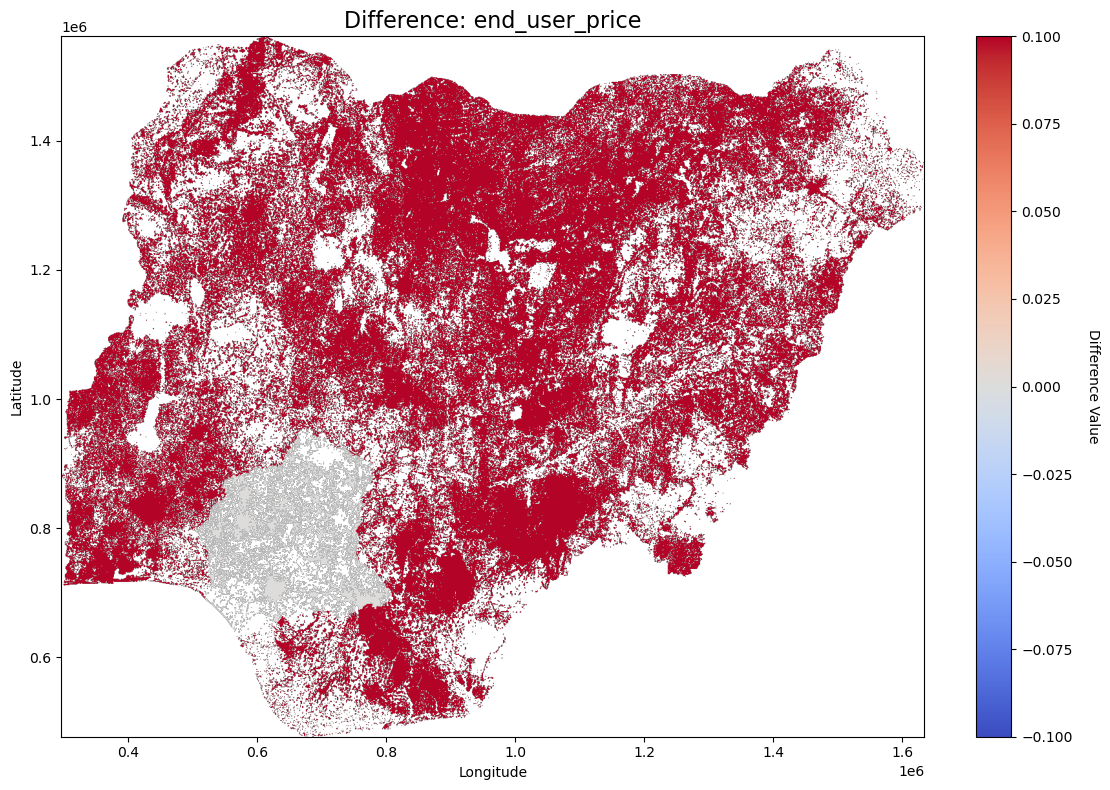

In [10]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

base_dir = r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\dataset"

file_base = os.path.join(base_dir, "end_user_price_NGA.tif")
file_risk = os.path.join(base_dir, "end_user_price_NGA_sensitivity_2.tif")

band_index = 19

with rasterio.open(file_base) as src_base, rasterio.open(file_risk) as src_risk:
    
    # Verifica preventiva sulle dimensioni dei raster
    if src_base.shape != src_risk.shape:
        print(f"Errore: Dimensioni non corrispondenti. Base: {src_base.shape}, Risk: {src_risk.shape}")
    
    band_base = src_base.read(band_index, masked=True)
    band_risk = src_risk.read(band_index, masked=True)
    
    difference = band_risk - band_base
    
    bounds = src_base.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, ax = plt.subplots(figsize=(14, 8))

valid_data = difference.compressed()

if valid_data.size > 0:
    # Calcolo il 98esimo percentile sui valori assoluti per tagliare gli estremi
    vmax = np.percentile(np.abs(valid_data), 98)
    vmin = -vmax
else:
    vmin, vmax = -1, 1

img = ax.imshow(difference, cmap='coolwarm', extent=extent, vmin=vmin, vmax=vmax)

ax.set_title('Difference: end_user_price', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Difference Value', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

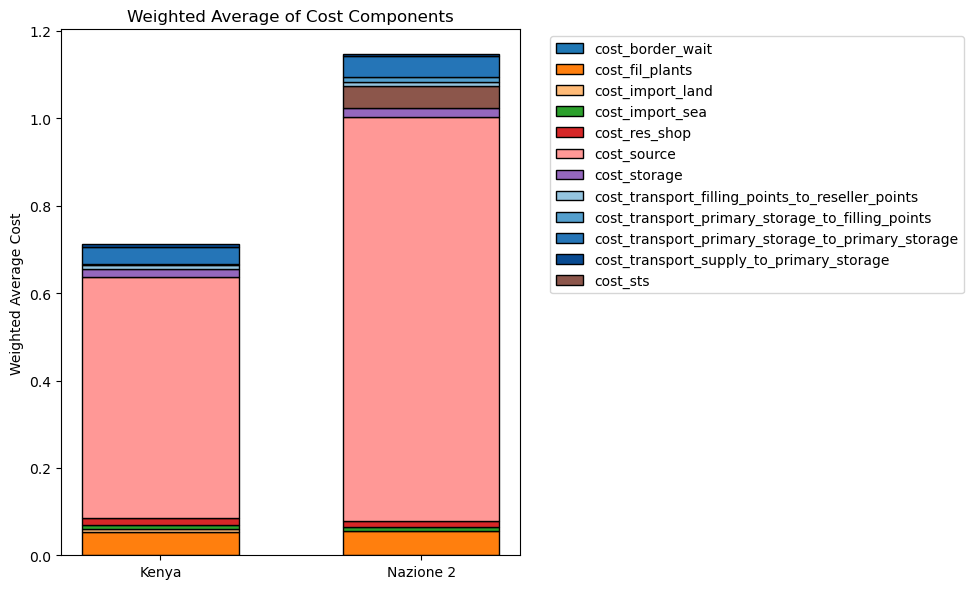

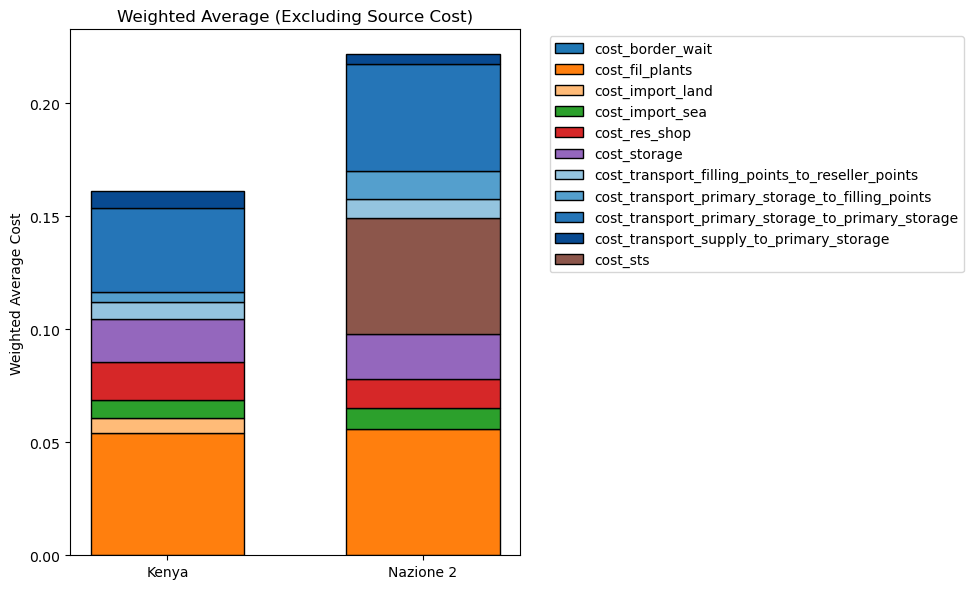

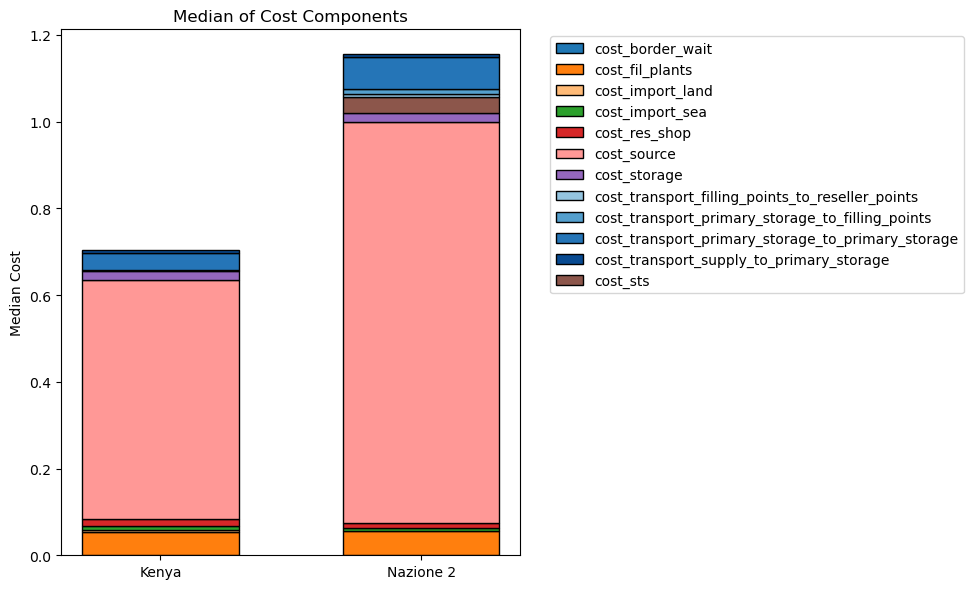

In [14]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Definisci i percorsi per i due file
# Inserisci il percorso corretto per la Nazione 2
files = {
    "Kenya": r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\ALTRI COUNTRY\KEN\supply_chain_layer_KEN.gpkg",
    "Nazione 2": r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\dataset\supply_chain_layer_NGA.gpkg"
}
layer_name = "reseller_points"
clients_col = 'clients'

all_data = {}
all_cost_cols = set()

# 2. Estrazione dati per ciascuna nazione
for country, file_path in files.items():
    gdf = gpd.read_file(file_path, layer=layer_name)
    
    # Seleziona colonne di costo
    cost_cols = [col for col in gdf.columns if str(col).startswith('cost_') and pd.api.types.is_numeric_dtype(gdf[col])]
    if 'cost_total' in cost_cols:
        cost_cols.remove('cost_total')
    
    # Aggiorna il set globale delle colonne di costo
    all_cost_cols.update(cost_cols)

    gdf_clean = gdf.dropna(subset=[clients_col]).copy()

    # Calcolo 1: Media ponderata
    weighted_avg = {}
    for col in cost_cols:
        valid_data = gdf_clean.dropna(subset=[col])
        total_valid_clients = valid_data[clients_col].sum()
        if total_valid_clients > 0:
            weighted_avg[col] = (valid_data[col] * valid_data[clients_col]).sum() / total_valid_clients
        else:
            weighted_avg[col] = 0

    # Calcolo 2: Media ponderata escluso "cost_source"
    weighted_avg_no_source = {col: val for col, val in weighted_avg.items() if col != 'cost_source'}

    # Calcolo 3: Mediana
    medians = gdf[cost_cols].median().to_dict()

    # Salva i risultati nel dizionario globale
    all_data[country] = {
        'weighted_avg': weighted_avg,
        'weighted_avg_no_source': weighted_avg_no_source,
        'medians': medians
    }

# --- Logica per la mappatura dei colori (Unificata per entrambe le nazioni) ---
all_cost_cols = sorted(list(all_cost_cols))
transport_cols = [col for col in all_cost_cols if col.startswith('cost_transport_')]
other_cols = [col for col in all_cost_cols if col not in transport_cols]

cost_colors = {}

transport_cmap = cm.Blues
for i, col in enumerate(transport_cols):
    shade_intensity = 0.4 + (0.5 * (i / max(1, len(transport_cols) - 1))) if len(transport_cols) > 1 else 0.7
    cost_colors[col] = transport_cmap(shade_intensity)

other_cmap = cm.tab20
for i, col in enumerate(other_cols):
    cost_colors[col] = other_cmap(i % 20)

# 3. Creazione dei grafici (Side-by-Side)
def plot_comparative_stacked_bar(metric_key, title, ylabel):
    plt.figure(figsize=(10, 6))
    
    countries = list(all_data.keys())
    x_positions = range(len(countries))
    
    # Set per evitare duplicati nella legenda
    plotted_labels = set()
    
    for i, country in enumerate(countries):
        bottom = 0
        country_dict = all_data[country][metric_key]
        
        for cost_name in all_cost_cols:
            # Usa .get() per gestire il caso in cui un costo esista in una nazione ma non nell'altra
            value = country_dict.get(cost_name, 0) 
            
            if value > 0:
                label = cost_name if cost_name not in plotted_labels else ""
                plt.bar(
                    i, 
                    value, 
                    bottom=bottom, 
                    label=label, 
                    color=cost_colors[cost_name], 
                    edgecolor='black',
                    width=0.6 # Stringe leggermente le barre per un aspetto migliore
                )
                bottom += value
                plotted_labels.add(cost_name)
                
    plt.title(title)
    plt.ylabel(ylabel)
    
    # Imposta le etichette dell'asse X con i nomi delle nazioni
    plt.xticks(x_positions, countries)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.tight_layout()
    plt.show()

# Genera i 3 plot comparativi
plot_comparative_stacked_bar(
    metric_key='weighted_avg', 
    title='Weighted Average of Cost Components', 
    ylabel='Weighted Average Cost'
)

plot_comparative_stacked_bar(
    metric_key='weighted_avg_no_source', 
    title='Weighted Average (Excluding Source Cost)', 
    ylabel='Weighted Average Cost'
)

plot_comparative_stacked_bar(
    metric_key='medians', 
    title='Median of Cost Components', 
    ylabel='Median Cost'
)

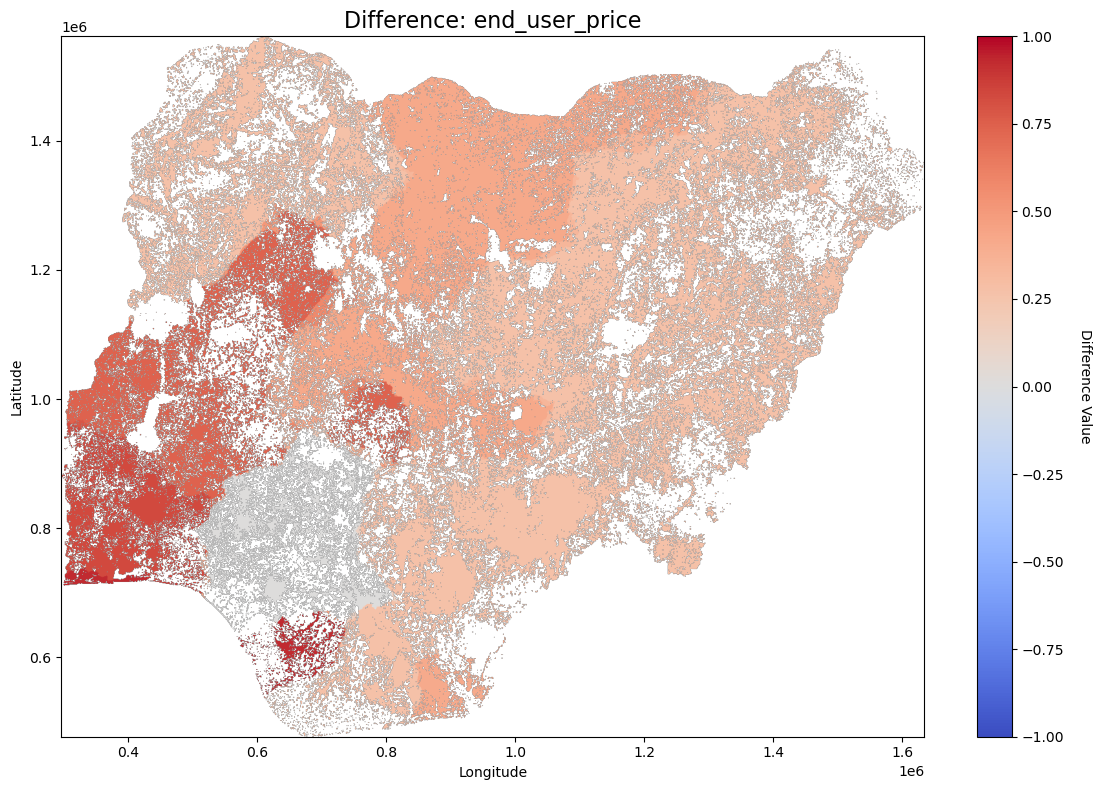

In [6]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

base_dir = r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\dataset"
scenario = "NGA_sensitivity_2"

file_base = os.path.join(base_dir, "end_user_price_NGA.tif")
file_risk = os.path.join(base_dir, "end_user_price_NGA_sensitivity_2.tif")

band_index = 19

with rasterio.open(file_base) as src_base, rasterio.open(file_risk) as src_risk:
    
    # Verifica preventiva sulle dimensioni dei raster
    if src_base.shape != src_risk.shape:
        print(f"Errore: Dimensioni non corrispondenti. Base: {src_base.shape}, Risk: {src_risk.shape}")
    
    band_base = src_base.read(band_index, masked=True)
    band_risk = src_risk.read(band_index, masked=True)
    
    difference = band_risk - band_base
    
    bounds = src_base.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, ax = plt.subplots(figsize=(14, 8))

vmin = -1
vmax = -vmin

valid_data = difference.compressed()

img = ax.imshow(difference, cmap='coolwarm', extent=extent, vmin=vmin, vmax=vmax)

ax.set_title('Difference: end_user_price', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Difference Value', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, f"difference_end_user_price_{scenario}.png"), dpi=600)
plt.show()

In [12]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Definisci i percorsi per i due file
# Inserisci il percorso corretto per la Nazione 2
files = {
    "Kenya": r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\ALTRI COUNTRY\KEN\supply_chain_layer_KEN.gpkg",
    "Nazione 2": r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\dataset\supply_chain_layer_NGA.gpkg"  # TODO: Sostituisci con il percorso corretto
}
layer_name = "reseller_points"
clients_col = 'clients'

all_data = {}
all_cost_cols = set()

# 2. Estrazione dati per ciascuna nazione
for country, file_path in files.items():
    gdf = gpd.read_file(file_path, layer=layer_name)
    
    # Seleziona colonne di costo
    cost_cols = [col for col in gdf.columns if str(col).startswith('cost_') and pd.api.types.is_numeric_dtype(gdf[col])]
    if 'cost_total' in cost_cols:
        cost_cols.remove('cost_total')
    
    # Aggiorna il set globale delle colonne di costo
    all_cost_cols.update(cost_cols)

    gdf_clean = gdf.dropna(subset=[clients_col]).copy()

    # Calcolo 1: Media ponderata
    weighted_avg = {}
    for col in cost_cols:
        valid_data = gdf_clean.dropna(subset=[col])
        total_valid_clients = valid_data[clients_col].sum()
        if total_valid_clients > 0:
            weighted_avg[col] = (valid_data[col] * valid_data[clients_col]).sum() / total_valid_clients
        else:
            weighted_avg[col] = 0

    # Calcolo 2: Media ponderata escluso "cost_source"
    weighted_avg_no_source = {col: val for col, val in weighted_avg.items() if col != 'cost_source'}

    # Calcolo 3: Mediana
    medians = gdf[cost_cols].median().to_dict()

    # Salva i risultati nel dizionario globale
    all_data[country] = {
        'weighted_avg': weighted_avg,
        'weighted_avg_no_source': weighted_avg_no_source,
        'medians': medians
    }

# --- Logica per la mappatura dei colori (Unificata per entrambe le nazioni) ---
all_cost_cols = sorted(list(all_cost_cols))
transport_cols = [col for col in all_cost_cols if col.startswith('cost_transport_')]
other_cols = [col for col in all_cost_cols if col not in transport_cols]

cost_colors = {}

transport_cmap = cm.Blues
for i, col in enumerate(transport_cols):
    shade_intensity = 0.4 + (0.5 * (i / max(1, len(transport_cols) - 1))) if len(transport_cols) > 1 else 0.7
    cost_colors[col] = transport_cmap(shade_intensity)

other_cmap = cm.tab20
for i, col in enumerate(other_cols):
    cost_colors[col] = other_cmap(i % 20)

# 3. Creazione dei grafici (Side-by-Side)
def plot_comparative_stacked_bar(metric_key, title, ylabel):
    plt.figure(figsize=(10, 6))
    
    countries = list(all_data.keys())
    x_positions = range(len(countries))
    
    # Set per evitare duplicati nella legenda
    plotted_labels = set()
    
    for i, country in enumerate(countries):
        bottom = 0
        country_dict = all_data[country][metric_key]
        
        for cost_name in all_cost_cols:
            # Usa .get() per gestire il caso in cui un

_IncompleteInputError: incomplete input (1680551423.py, line 86)

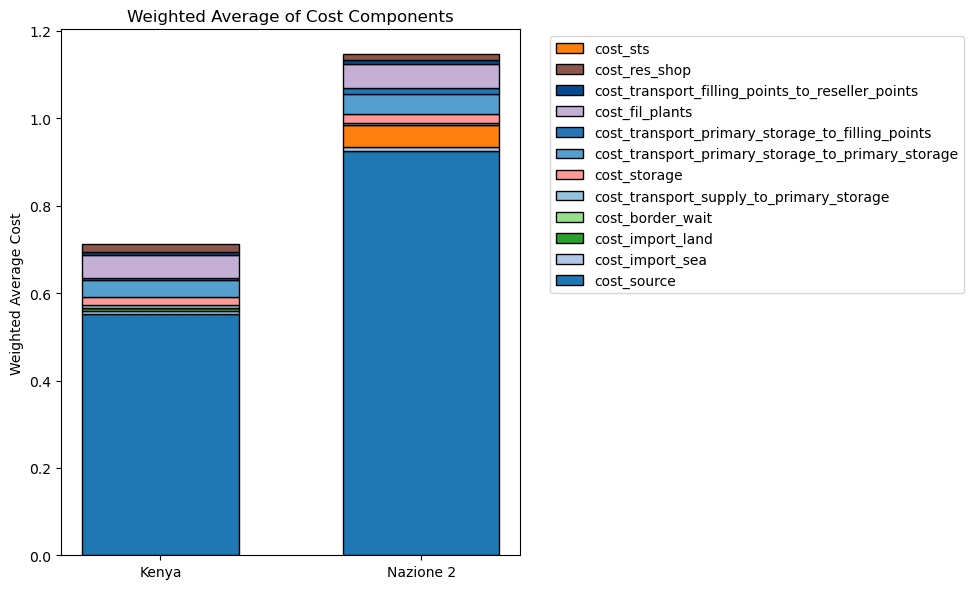

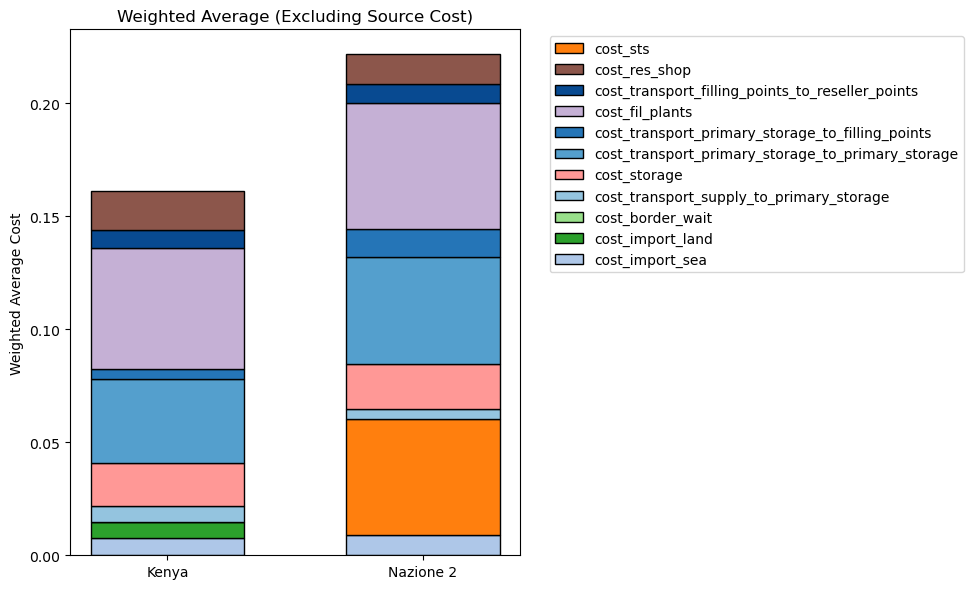

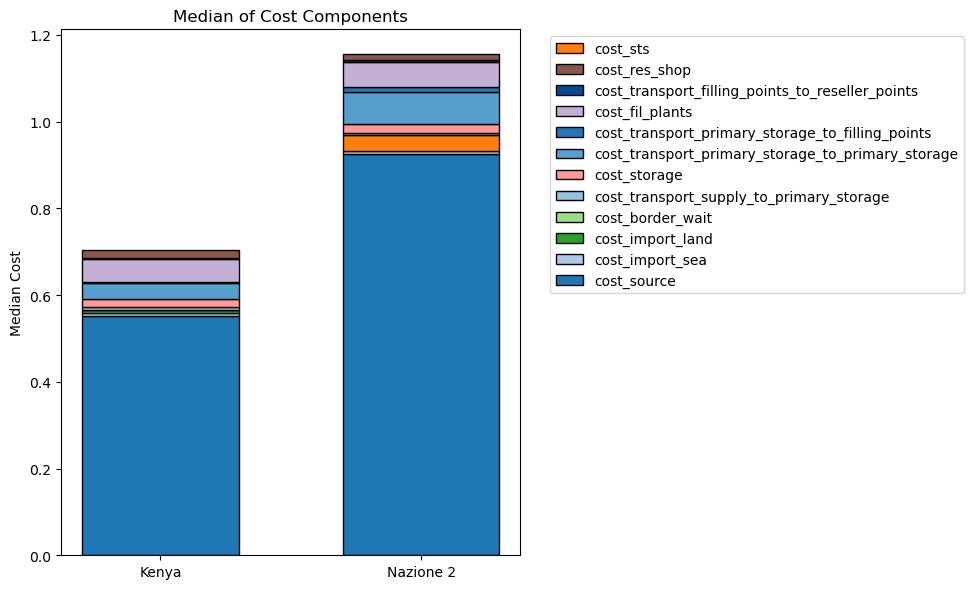

In [16]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Definisci i percorsi per i due file
files = {
    "Kenya": r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\ALTRI COUNTRY\KEN\supply_chain_layer_KEN.gpkg",
    "Nazione 2": r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\dataset\supply_chain_layer_NGA.gpkg"  # TODO: Sostituisci con il percorso corretto
}
layer_name = "reseller_points"
clients_col = 'clients'

all_data = {}
all_cost_cols = []  # Modifica: Uso una lista per preservare l'ordine

# 2. Estrazione dati per ciascuna nazione
for country, file_path in files.items():
    gdf = gpd.read_file(file_path, layer=layer_name)
    
    # Seleziona colonne di costo mantenendo l'ordine originale del file
    cost_cols = [col for col in gdf.columns if str(col).startswith('cost_') and pd.api.types.is_numeric_dtype(gdf[col])]
    if 'cost_total' in cost_cols:
        cost_cols.remove('cost_total')
    
    # Aggiorna la lista globale delle colonne senza alterare l'ordine esistente
    for col in cost_cols:
        if col not in all_cost_cols:
            all_cost_cols.append(col)

    gdf_clean = gdf.dropna(subset=[clients_col]).copy()

    # Calcolo 1: Media ponderata
    weighted_avg = {}
    for col in cost_cols:
        valid_data = gdf_clean.dropna(subset=[col])
        total_valid_clients = valid_data[clients_col].sum()
        if total_valid_clients > 0:
            weighted_avg[col] = (valid_data[col] * valid_data[clients_col]).sum() / total_valid_clients
        else:
            weighted_avg[col] = 0

    # Calcolo 2: Media ponderata escluso "cost_source"
    weighted_avg_no_source = {col: val for col, val in weighted_avg.items() if col != 'cost_source'}

    # Calcolo 3: Mediana
    medians = gdf[cost_cols].median().to_dict()

    # Salva i risultati nel dizionario globale
    all_data[country] = {
        'weighted_avg': weighted_avg,
        'weighted_avg_no_source': weighted_avg_no_source,
        'medians': medians
    }

# --- Logica per la mappatura dei colori ---
# Separo le categorie di costo per assegnare i colori, ma il plotting finale userà all_cost_cols
transport_cols = [col for col in all_cost_cols if col.startswith('cost_transport_')]
other_cols = [col for col in all_cost_cols if col not in transport_cols]

cost_colors = {}

transport_cmap = cm.Blues
for i, col in enumerate(transport_cols):
    shade_intensity = 0.4 + (0.5 * (i / max(1, len(transport_cols) - 1))) if len(transport_cols) > 1 else 0.7
    cost_colors[col] = transport_cmap(shade_intensity)

other_cmap = cm.tab20
for i, col in enumerate(other_cols):
    cost_colors[col] = other_cmap(i % 20)

# 3. Creazione dei grafici (Side-by-Side)
def plot_comparative_stacked_bar(metric_key, title, ylabel):
    plt.figure(figsize=(10, 6))
    
    countries = list(all_data.keys())
    x_positions = range(len(countries))
    
    plotted_labels = set()
    
    for i, country in enumerate(countries):
        bottom = 0
        country_dict = all_data[country][metric_key]
        
        # Iterazione su all_cost_cols che ora mantiene l'ordine originale dei file
        for cost_name in all_cost_cols:
            value = country_dict.get(cost_name, 0) 
            
            if value > 0:
                label = cost_name if cost_name not in plotted_labels else ""
                plt.bar(
                    i, 
                    value, 
                    bottom=bottom, 
                    label=label, 
                    color=cost_colors[cost_name], 
                    edgecolor='black',
                    width=0.6 
                )
                bottom += value
                plotted_labels.add(cost_name)
                
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(x_positions, countries)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        # Inverte l'ordine della legenda per farlo combaciare con l'ordine visivo (dal basso verso l'alto)
        plt.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.tight_layout()
    plt.show()

# Genera i 3 plot comparativi
plot_comparative_stacked_bar(
    metric_key='weighted_avg', 
    title='Weighted Average of Cost Components', 
    ylabel='Weighted Average Cost'
)

plot_comparative_stacked_bar(
    metric_key='weighted_avg_no_source', 
    title='Weighted Average (Excluding Source Cost)', 
    ylabel='Weighted Average Cost'
)

plot_comparative_stacked_bar(
    metric_key='medians', 
    title='Median of Cost Components', 
    ylabel='Median Cost'
)